In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from rapidfuzz import fuzz, process
from sklearn.model_selection import cross_validate
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import SparsePCA
from sklearn.model_selection import train_test_split
from joblib import Parallel, delayed

from scholarlm.utils import get_filenames_in_directory, get_foldernames_in_directory, correct_image_orientation, tokenize
from dotenv import load_dotenv
load_dotenv()

INFO 02-11 09:50:05 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 02-11 09:50:17 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


True

### Load Data

In [2]:
main_directory = os.getenv("POND_PATH")
data_directory = os.getenv("POND_DATA_PATH")
pdf_directory = os.getenv("POND_PDF_PATH")
text_directory = os.getenv("POND_TEXT_PATH")
image_directory = os.getenv("POND_IMAGE_PATH")

In [3]:
# Directory
with open(os.path.join(main_directory, "directory.json"), "r") as f:
    paper_info = json.load(f)


paper_subset = [
    'physical_and_chemical_limnological',
    'physical-chemical_influences',
    'prairie_wetland',
    'net_heterotrophy',
    'habitat_characteristics',
    'biodiversity_of_constructed',
    'fish_production_in_lakes',
    'long-term_stability',
    'diversity_of_macroinvertebrates',
    'impact_of_macrophytes'
]

paper_info = {k:v for k,v in paper_info.items() if k in paper_subset}


registered_titles = [entry['title'] for entry in paper_info.values()]
registered_titles.sort()
#registered_titles = [registered_titles[i] for i in finished_papers]

# Original dataset
pond_df = pd.read_csv(os.path.join(data_directory, "pond_data_corrected.csv"), encoding_errors='ignore')
pond_df = pond_df.loc[pond_df.title.isin(registered_titles)]
pond_df = pond_df.reset_index(drop=True)
pond_df.rename(columns={'measurement': 'feature'}, inplace=True)
'''
pond_df = pond_data.loc[:,['author', 'title', 'pondname', 'location', 'author_term',
            'max_depth_m', 'mean_surfacearea_m2', 'macrophytes_percentcover', 'ph', 'tn_ugpl', 'tp_ugpl', 'chla_ugpl']]
pond_df.columns = ['author', 'title', 'name', 'location', 'ecosystem',
            'max_depth', 'surface_area', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla']

# Split the dataframe's rows so that each measurement is in its own row
pond_df = pond_df.melt(id_vars=['author', 'title', 'name', 'location', 'ecosystem'], 
                       value_vars=['max_depth', 'surface_area', 'vegetation_cover', 'ph', 'tn', 'tp', 'chla'],
                       var_name='measurement', value_name='value')
pond_df = pond_df.dropna(subset=['value'])
pond_df = pond_df.reset_index(drop=True)
n_entries = pond_df.shape[0]

pond_df['date'] = None
pond_df['state'] = None

pond_df = pond_df.loc[:, ['author', 'title', 'name', 'location', 'ecosystem', 'date', 'state', 'measurement', 'value']]

pond_df.to_csv(os.path.join(data_directory, "pond_data_cleaned.csv"), index=False)
'''

'\npond_df = pond_data.loc[:,[\'author\', \'title\', \'pondname\', \'location\', \'author_term\',\n            \'max_depth_m\', \'mean_surfacearea_m2\', \'macrophytes_percentcover\', \'ph\', \'tn_ugpl\', \'tp_ugpl\', \'chla_ugpl\']]\npond_df.columns = [\'author\', \'title\', \'name\', \'location\', \'ecosystem\',\n            \'max_depth\', \'surface_area\', \'vegetation_cover\', \'ph\', \'tn\', \'tp\', \'chla\']\n\n# Split the dataframe\'s rows so that each measurement is in its own row\npond_df = pond_df.melt(id_vars=[\'author\', \'title\', \'name\', \'location\', \'ecosystem\'], \n                       value_vars=[\'max_depth\', \'surface_area\', \'vegetation_cover\', \'ph\', \'tn\', \'tp\', \'chla\'],\n                       var_name=\'measurement\', value_name=\'value\')\npond_df = pond_df.dropna(subset=[\'value\'])\npond_df = pond_df.reset_index(drop=True)\nn_entries = pond_df.shape[0]\n\npond_df[\'date\'] = None\npond_df[\'state\'] = None\n\npond_df = pond_df.loc[:, [\'author\'

In [4]:
def process(
    result_df,
    conversion_table
):
    result_df = result_df.copy()

    # Drop rows without any measurements
    result_df = result_df.dropna(subset=['value'])
    result_df = result_df.reset_index(drop=True)

    # Convert units
    processed_values = [val for val in result_df.loc[:,'value']]
    for row_idx, row in result_df.iterrows():
        #measurement_type = row['measurement']
        feature_type = row['feature']
        val = row['value']
        unit = row['units']
        if conversion_table.get(feature_type) is not None:
            if conversion_table[feature_type].get(unit) is not None:
                conversion_factor = conversion_table[feature_type][unit]
                processed_values[row_idx] = val * conversion_factor


    result_df['processed_value'] = processed_values
    result_df = result_df.dropna(subset=['processed_value'])
    result_df = result_df.reset_index(drop=True)

    # Drop all unit columns
    #result_df = result_df.drop(columns=["units"])

    # Drop exact duplicates
    result_df = result_df.drop_duplicates()

    # Reset index
    result_df = result_df.reset_index(drop=True)

    return result_df


conversion_table = {
    'max_depth': {"cm": 0.01, "feet": 0.3048, "km": 1000, "m": 1},
    'surface_area': {"km^2": 1e6, "ha": 1e4, "mi^2": 2.59e6, "m^2": 1, "acres": 4046.86},
    'vegetation_cover': {"percent": 1, "fraction": 100},
    'tn': {"mg/L": 1000, "µg/L": 1, "μmol/L": 14.01, "ppm": 1000, "ppb": 1},
    'tp': {"mg/L": 1000, "µg/L": 1, "μmol/L": 30.97, "ppm": 1000, "ppb": 1},
    'chla': {"mg/L": 1000, "µg/L": 1},
    'ph': {},
    'latitude': {},
    'longitude': {}
}

In [13]:
def deduplicate_data(data):
    unique_entries = {}
    deduplicated_data = []
    for entry in data:
        key = (entry['document_id'], entry['feature'], entry['name'], entry['value'])
        if key not in unique_entries:
            unique_entries[key] = entry
            deduplicated_data.append(entry)
    return deduplicated_data

In [14]:
#with open("../data/01_20_26/ten_validated_combined.json", "r") as f:
#    result_dict = json.load(f)

with open("../data/experiments/2026_02_11/new_ten_judged_combined.json", "r") as f:
    result_dict = json.load(f)

result_dict = deduplicate_data(result_dict)
#scores = ['context_scores', 'parametric_scores', 'copying_scores', 'linear_probes', 'measurement_names', 'entity_names']
drops = ['feature_terms']
result_dict = [{k:v for k,v in entry.items() if k not in drops} for entry in result_dict]
result_df = pd.DataFrame(result_dict)

In [17]:
#result_df = result_df.loc[result_df.title.isin(registered_titles)]
result_df = result_df.reset_index(drop=True)

ignore_features = ['latitude', 'longitude'] # Ignoring these for now because they are not in the original dataset

result_df = result_df.loc[~result_df.feature.isin(ignore_features)]
result_df['value'] = result_df['value'].str.replace(',', '')  # Remove commas from numbers
result_df['value'] = pd.to_numeric(result_df['value'], errors='coerce')
result_df = process(result_df, conversion_table)
result_df.sort_values(by=["document_id"], inplace=True)
result_df = result_df.reset_index(drop=True)

In [22]:
result_df

,document_id,context,units,name,abbreviations,location,site,state,date,ecosystem,...,judgement_gemini,judgement_confidence_gemini,judgement_claude,judgement_confidence_claude,judgement_llama,judgement_confidence_llama,judgement_combined,row_index,column_index,processed_value
0,0,Fig. 1 Lakes sampled in the coastal plain of R...,ha,Rincão,Ri,"Rio Grande do Sul, Brazil",L,None,January-May 2007,lake,...,True,None,True,None,true,0.687289,True,NaN,NaN,600000.00
1,0,Fig. 1 Lakes sampled in the coastal plain of R...,ha,Passos,Pa,"Rio Grande do Sul, Brazil",L,None,January-May 2007,lake,...,True,None,True,None,true,0.687289,True,NaN,NaN,690000.00
2,0,Table 3 Comparisons between littoral (L) and ...,percent,Passos,Pa,"Rio Grande do Sul, Brazil",L,None,January-May 2007,lake,...,False,None,False,None,false,0.882497,False,NaN,NaN,42.19
3,0,Table 3 Comparisons between littoral (L) and ...,percent,Passos,Pa,"Rio Grande do Sul, Brazil",P,None,January-May 2007,lake,...,False,None,False,None,false,0.778801,False,NaN,NaN,16.89
4,0,Fig. 1 Lakes sampled in the coastal plain of R...,ha,Suzana,Sz,"Rio Grande do Sul, Brazil",L,None,January-May 2007,lake,...,True,None,True,None,true,0.687289,True,NaN,NaN,970000.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,9,Table 1. Basic environmental characteristics a...,None,Podbanské,Podbanské,"Tatras, Slovakia",Podbanské,2,2012-14,pond,...,True,None,True,None,false,0.778801,True,Podbanské,Water pH_min,7.60
380,9,Table 1. Basic environmental characteristics a...,m^2,Zverovka,Zverovka,"Tatras, Slovakia",Zverovka,1,2012-14,pond,...,True,None,True,None,false,1.000000,True,Podbanské,Pond area (m²)_min,2315.00
381,9,Table 1. Basic environmental characteristics a...,None,Zverovka,Zverovka,"Tatras, Slovakia",Zverovka,1,2012-14,pond,...,True,None,True,None,false,0.778801,True,Zverovka,Water pH_min,6.45
382,9,Table 1. Basic environmental characteristics a...,m^2,Čierne pleso pri Vyšných Hágoch,Čierne pleso pri Vyšných Hágoch,"Tatras, Slovakia",Čierne pleso pri Vyšných Hágoch,1,2012-14,pond,...,True,None,True,None,false,0.882497,True,Podbanské,Pond area (m²)_min,85.00


### Match with ground truth

In [20]:
def match_datapoints(ground_truth, extracted):
    edges = []
    edge_weights = []
    for i, row_gt in ground_truth.iterrows():
        for j, row_ex in extracted.iterrows():
            if (
                row_gt['document_id'] == row_ex['document_id'] and
                #row_gt['measurement'] == row_ex['measurement'] and
                row_gt['feature'] == row_ex['feature'] and
                np.isclose(row_gt['value'], row_ex['processed_value'], atol=1e-3)
            ):
                if row_gt['name'] is None or row_ex['name'] is None:
                    name_similarity = 0.0
                else:
                    name1 = row_gt['name'].lower().strip()
                    name2 = row_ex['name'].lower().strip()
                    name_similarity = fuzz.ratio(name1, name2) / 100.0

                if row_gt['location'] is None or row_ex['location'] is None:
                    location_similarity = 0.0
                else:
                    location1 = row_gt['location'].lower().strip()
                    location2 = row_ex['location'].lower().strip()
                    location_similarity = fuzz.ratio(location1, location2) / 100.0

                if row_gt['ecosystem'] is None or row_ex['ecosystem'] is None:
                    ecosystem_similarity = 0.0
                else:
                    ecosystem1 = row_gt['ecosystem'].lower().strip()
                    ecosystem2 = row_ex['ecosystem'].lower().strip()
                    ecosystem_similarity = fuzz.ratio(ecosystem1, ecosystem2) / 100.0
                
                weight = (name_similarity + location_similarity + ecosystem_similarity) / 3.0
                edges.append((i, j))
                edge_weights.append(weight)

    print(f"Total edges found: {len(edges)}")
    # Create a bipartite graph and find maximum weight matching
    G = nx.Graph()
    G.add_edges_from([(f"gt_{i}", f"ex_{j}", {'weight': w}) for (i, j), w in zip(edges, edge_weights)])
    matching = nx.algorithms.matching.max_weight_matching(G)
    index_matching = []
    for i, j in matching:
        if i.startswith("gt_"):
            index_matching.append((int(i[3:]), int(j[3:])))
        else:
            index_matching.append((int(j[3:]), int(i[3:])))
    
    return index_matching, edges, edge_weights


def estimate_precision_recall(ground_truth, extracted):
    total_ground_truth = ground_truth.shape[0]
    total_extracted = extracted.shape[0]

    matching, edges, edge_weights = match_datapoints(ground_truth, extracted)

    true_positives = len(matching)
    precision = true_positives / total_extracted if total_extracted > 0 else 0
    recall = true_positives / total_ground_truth if total_ground_truth > 0 else 0

    return recall, precision

In [21]:
matching, edges, edge_weights = match_datapoints(pond_df, result_df)

KeyError: 'document_id'

In [ ]:
len(matching)

674

In [38]:
gt_to_extracted_dict = {}
edge_weights_dict = {}
for i, (m1,m2) in enumerate(edges):
    w = edge_weights[i]
    if m1 not in gt_to_extracted_dict:
        gt_to_extracted_dict[m1] = {m2}
    else:
        gt_to_extracted_dict[m1].add(m2)
    edge_weights_dict[(m1, m2)] = w

In [69]:
#pond_idx = list(gt_to_extracted_dict.keys())[595]
pond_idx = 595

print("Ground truth datapoint:")
display(pond_df.loc[pond_idx,:])
print("------------------------" * 3)

print("Extracted matching datapoints:")
for ex_idx in gt_to_extracted_dict[pond_idx]:
    print(f"Weight: {edge_weights_dict[(pond_idx, ex_idx)]:.4f}")
    display(result_df.loc[ex_idx,:])
    print("------------------------" * 3)


Ground truth datapoint:


author                                                lim et al.
title          physical and chemical limnological characteris...
name                                                         baa
location                                 bathurst island; canada
ecosystem                                                   lake
measurement                                                   ph
value                                                        8.2
Name: 595, dtype: object

------------------------------------------------------------------------
Extracted matching datapoints:
Weight: 0.1778


title              physical and chemical limnological characteris...
author                                                    lim et al.
year                                                            2001
paper_code                        physical_and_chemical_limnological
document_id                                                        0
context            Table 1. (continued)\n\n<table number="3">\n  ...
name                                                              BV
date                                                      1994-07-14
location                                      75°39.14 N, 98°02.59 W
ecosystem                                                       pond
page_number                                                        6
measurement                                                       ph
measurement_id                                                  2971
page_logprob                                                -0.00117
table_number                      

------------------------------------------------------------------------
Weight: 0.1778


...

------------------------------------------------------------------------
Weight: 0.5111


title              physical and chemical limnological characteris...
author                                                    lim et al.
year                                                            2001
paper_code                        physical_and_chemical_limnological
document_id                                                        0
context            Table 1. (continued)\n\n<table number="3">\n  ...
name                                                              BZ
date                                                      1994-07-14
location                                      75°43.25 N, 98°40.68 W
ecosystem                                                       lake
page_number                                                        6
measurement                                                       ph
measurement_id                                                  3587
page_logprob                                               -0.005234
table_number                      

------------------------------------------------------------------------
Weight: 0.1778


title              physical and chemical limnological characteris...
author                                                    lim et al.
year                                                            2001
paper_code                        physical_and_chemical_limnological
document_id                                                        0
context            Table 1. (continued)\n\n<table number="3">\n  ...
name                                                              BC
date                                                      1994-07-14
location                                      75°03.74 N, 97°59.74 W
ecosystem                                                       pond
page_number                                                        6
measurement                                                       ph
measurement_id                                                    45
page_logprob                                               -0.000911
table_number                      

------------------------------------------------------------------------


In [14]:
gt_matched = np.array([False] * pond_df.shape[0])
ex_matched = np.array([False] * result_df.shape[0])
for gt_idx, ex_idx in matching:
    gt_matched[gt_idx] = True
    ex_matched[ex_idx] = True

unmatched_gt = np.where(~gt_matched)[0]
unmatched_ex = np.where(~ex_matched)[0]

matched_gt_df = pond_df[gt_matched == True]
unmatched_gt_df = pond_df[gt_matched == False]
unmatched_gt_titles = unmatched_gt_df.title.value_counts().index

matched_ex_df = result_df[ex_matched == True]
unmatched_ex_df = result_df[ex_matched == False]
unmatched_ex_titles = unmatched_ex_df.title.value_counts().index

In [16]:
unmatched_gt_df.title.value_counts()

title
physical and chemical limnological characteristics of 38 lakes and ponds on bathurst island; nunavut; canadian high arctic    71
impact of macrophytes on phytoplankton in eutrophic peri-urban ponds; implications for pond management and restoration        66
physical-chemical influences on vernal zooplankton community structure in small lakes and wetlands of wisconsin; usa          55
prairie wetland communities recover at different rates following hydrological restoration                                     53
net heterotrophy in small danish lakes: a widespread feature over gradients in trophic status and land cover                  37
diversity of macroinvertebrates positively correlates with diversity of macrophytes in karst ponds                            35
habitat characteristics and odonate diversity in mountain ponds of central italy                                              30
biodiversity of constructed wetlands for wastewater treatment                              

In [17]:
matched_gt_df.title.value_counts()

title
habitat characteristics and odonate diversity in mountain ponds of central italy                                               125
physical-chemical influences on vernal zooplankton community structure in small lakes and wetlands of wisconsin; usa           107
prairie wetland communities recover at different rates following hydrological restoration                                       91
physical and chemical limnological characteristics of 38 lakes and ponds on bathurst island; nunavut; canadian high arctic      81
long-term stability of cladoceran assemblages in small; shallow; canadian shield lakes experiencing marked calcium declines     56
fish production in lakes as a guide for estimating production in proposed reservoirs                                            56
biodiversity of constructed wetlands for wastewater treatment                                                                   54
net heterotrophy in small danish lakes: a widespread feature over gradients i

In [530]:
title = "long-term stability of cladoceran assemblages in small; shallow; canadian shield lakes experiencing marked calcium declines"
gt_title_df = pond_df.loc[pond_df.title == title]
umatched_gt_title_df = unmatched_gt_df.loc[unmatched_gt_df.title == title]
ex_title_df = result_df.loc[result_df.title == title]
unmatched_ex_title_df = unmatched_ex_df.loc[unmatched_ex_df.title == title]

In [16]:
unmatched_ex_df.judgement_combined.value_counts()

judgement_combined
False    433
True     226
Name: count, dtype: int64

## Validated Results

In [50]:
# Include matchings to the validation status:
matching_status = np.zeros(len(result_df), dtype=bool)
for gt_idx, ex_idx in matching:
    matching_status[ex_idx] = True

result_df['validation'] = result_df['judgement_combined'] | matching_status
validation_labels = result_df['validation']

## Hallucination Detection

### Judge

In [52]:
labels = validation_labels.astype(bool).to_numpy()

prediction_dict = {
    "llama": result_df['judgement_llama'],
    "gpt": result_df['judgement_gpt'],
    "gemini": result_df['judgement_gemini'],
    "claude": result_df['judgement_claude'],
}

for model_name, preds_series in prediction_dict.items():
    preds = preds_series.astype(bool).to_numpy()

    tp = int(((preds == True) & (labels == True)).sum())
    tn = int(((preds == False) & (labels == False)).sum())
    fp = int(((preds == True) & (labels == False)).sum())
    fn = int(((preds == False) & (labels == True)).sum())

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
    denom = fp + tn
    fpr = (fp / denom) if denom > 0 else float('nan')

    print(f"Model: {model_name}")
    print(f"  TP={tp}, FP={fp}, TN={tn}, FN={fn}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  False positive rate (FP/(FP+TN)): {fpr:.4f}")
    print()

Model: llama
  TP=312, FP=19, TN=414, FN=588
  Accuracy: 0.5446
  False positive rate (FP/(FP+TN)): 0.0439

Model: gpt
  TP=811, FP=10, TN=423, FN=89
  Accuracy: 0.9257
  False positive rate (FP/(FP+TN)): 0.0231

Model: gemini
  TP=809, FP=72, TN=361, FN=91
  Accuracy: 0.8777
  False positive rate (FP/(FP+TN)): 0.1663

Model: claude
  TP=665, FP=5, TN=428, FN=235
  Accuracy: 0.8200
  False positive rate (FP/(FP+TN)): 0.0115



### Next token probabilities

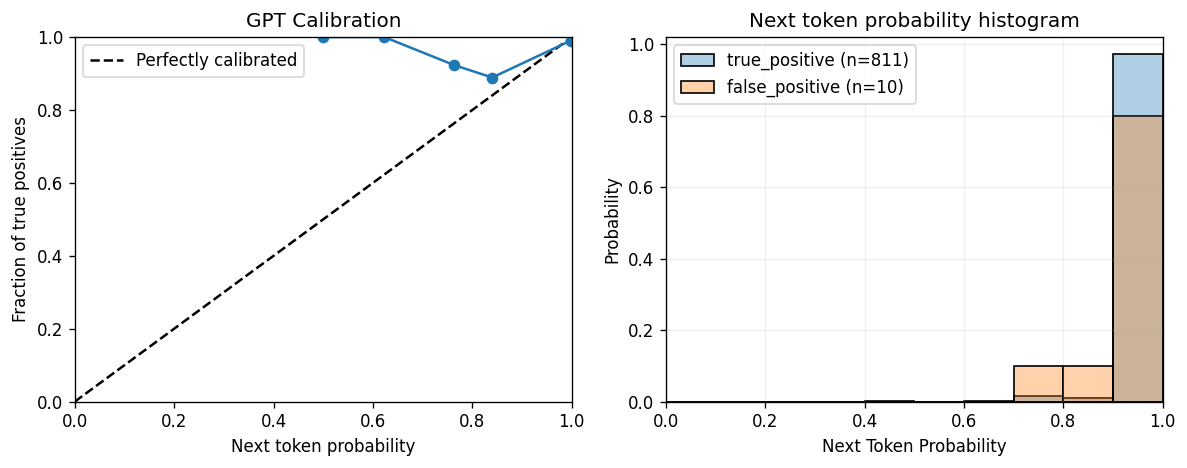

In [56]:
# Predicted probabilities for the positive class
idxs = np.where(result_df['judgement_gpt'].to_numpy())[0]
idxs_true_positive = np.where(result_df['judgement_gpt'].to_numpy() & result_df['validation'].to_numpy())[0]
idxs_false_positive = np.where(result_df['judgement_gpt'].to_numpy() & ~result_df['validation'].to_numpy())[0]
p_true_positive = result_df['judgement_confidence_gpt'].to_numpy()[idxs_true_positive]
p_false_positive = result_df['judgement_confidence_gpt'].to_numpy()[idxs_false_positive]

p_test = result_df['judgement_confidence_gpt'].to_numpy()[idxs]
y_test = result_df['validation'].to_numpy()[idxs]

# Reliability diagram data
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy='uniform')

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

# (1) Calibration diagram
ax[0].plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax[0].plot(mean_pred, frac_pos, marker="o")
ax[0].set_xlabel("Next token probability")
ax[0].set_ylabel("Fraction of true positives")
ax[0].set_title("GPT Calibration")
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].legend()

# (2) Probability histogram
bins = np.linspace(0.0, 1.0, 11)  # 20 equal-width bins on [0, 1]
sns.histplot(
    p_true_positive,
    bins=bins,
    stat="probability",
    color="tab:blue",
    alpha=0.35,
    label=f"true_positive (n={len(p_true_positive)})",
    ax=ax[1],
)

sns.histplot(
    p_false_positive,
    bins=bins,
    stat="probability",
    color="tab:orange",
    alpha=0.35,
    label=f"false_positive (n={len(p_false_positive)})",
    ax=ax[1],
)

ax[1].set_xlim(0, 1)
ax[1].set_xlabel("Next Token Probability")
ax[1].set_ylabel("Probability")
ax[1].set_title("Next token probability histogram")
ax[1].legend()
ax[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


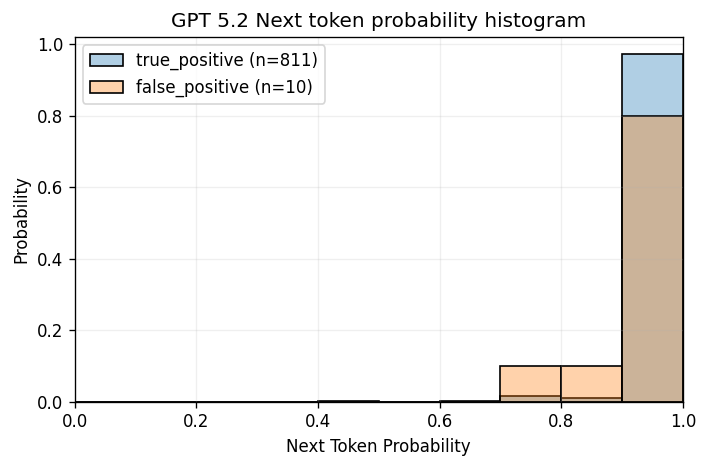

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=120)
bins = np.linspace(0.0, 1.0, 11)  # 20 equal-width bins on [0, 1]
sns.histplot(
    p_true_positive,
    bins=bins,
    stat="probability",
    color="tab:blue",
    alpha=0.35,
    label=f"true_positive (n={len(p_true_positive)})",
    ax=ax,
)

sns.histplot(
    p_false_positive,
    bins=bins,
    stat="probability",
    color="tab:orange",
    alpha=0.35,
    label=f"false_positive (n={len(p_false_positive)})",
    ax=ax,
)

ax.set_xlim(0, 1)
ax.set_xlabel("Next Token Probability")
ax.set_ylabel("Probability")
ax.set_title("GPT 5.2 Next token probability histogram")
ax.legend()
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

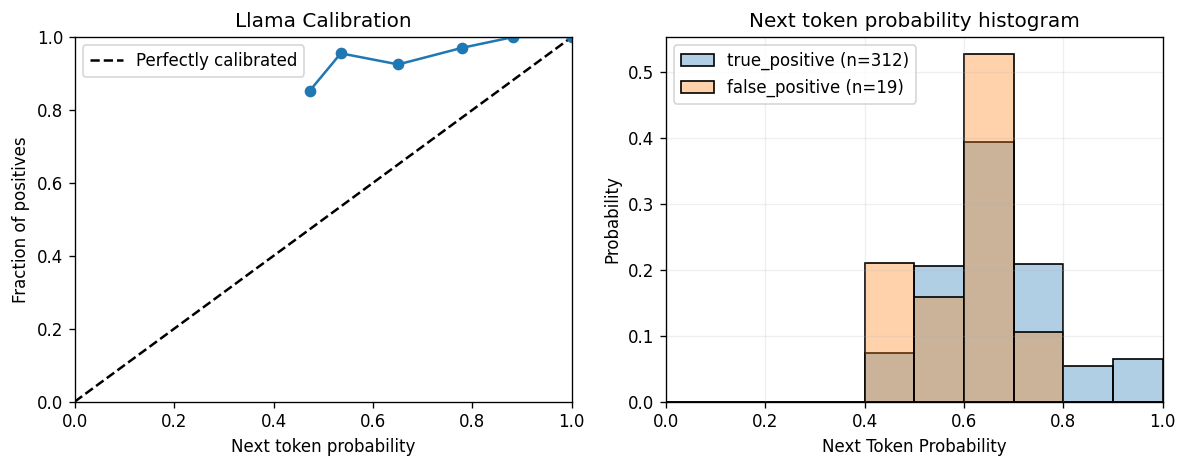

In [55]:
# Predicted probabilities for the positive class
idxs = np.where(result_df['judgement_llama'].to_numpy())[0]
idxs_true_positive = np.where(result_df['judgement_llama'].to_numpy() & result_df['validation'].to_numpy())[0]
idxs_false_positive = np.where(result_df['judgement_llama'].to_numpy() & ~result_df['validation'].to_numpy())[0]
p_true_positive = result_df['judgement_confidence_llama'].to_numpy()[idxs_true_positive]
p_false_positive = result_df['judgement_confidence_llama'].to_numpy()[idxs_false_positive]

p_test = result_df['judgement_confidence_llama'].to_numpy()[idxs]
y_test = result_df['validation'].to_numpy()[idxs]

# Reliability diagram data
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy='uniform')

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

# (1) Calibration diagram
ax[0].plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax[0].plot(mean_pred, frac_pos, marker="o")
ax[0].set_xlabel("Next token probability")
ax[0].set_ylabel("Fraction of positives")
ax[0].set_title("Llama Calibration")
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].legend()

# (2) Probability histogram
bins = np.linspace(0.0, 1.0, 11)  # 20 equal-width bins on [0, 1]
sns.histplot(
    p_true_positive,
    bins=bins,
    stat="probability",
    color="tab:blue",
    alpha=0.35,
    label=f"true_positive (n={len(p_true_positive)})",
    ax=ax[1],
)

sns.histplot(
    p_false_positive,
    bins=bins,
    stat="probability",
    color="tab:orange",
    alpha=0.35,
    label=f"false_positive (n={len(p_false_positive)})",
    ax=ax[1],
)

ax[1].set_xlim(0, 1)
ax[1].set_xlabel("Next Token Probability")
ax[1].set_ylabel("Probability")
ax[1].set_title("Next token probability histogram")
ax[1].legend()
ax[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


In [42]:
# GPT:
'''
idxs = np.where(~result_df['judgement_gpt'].to_numpy())
probs = result_df['judgement_confidence_gpt'].to_numpy()[idxs]
#labels = (result_df['validation_gpt'] != result_df['validation']).to_numpy()

# Train a logistic regression model
X = probs.reshape(-1, 1)
y = hallucination_labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
accuracy = (y_pred == y_test).sum() / len(y_test)
recall = (y_pred & y_test).sum() / y_test.sum()

print(f"GPT probability model accuracy: {accuracy:.4f} ({(y_pred == y_test).sum()}/{len(y_test)})")
print(f"GPT probability model recall: {recall:.4f} ({(y_pred & y_test).sum()}/{y_test.sum()})")
'''

'\nidxs = np.where(~result_df[\'judgement_gpt\'].to_numpy())\nprobs = result_df[\'judgement_confidence_gpt\'].to_numpy()[idxs]\n#labels = (result_df[\'validation_gpt\'] != result_df[\'validation\']).to_numpy()\n\n# Train a logistic regression model\nX = probs.reshape(-1, 1)\ny = hallucination_labels\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)\nlog_reg = LogisticRegression()\nlog_reg.fit(X_train, y_train)\ny_pred = log_reg.predict(X_test)\naccuracy = (y_pred == y_test).sum() / len(y_test)\nrecall = (y_pred & y_test).sum() / y_test.sum()\n\nprint(f"GPT probability model accuracy: {accuracy:.4f} ({(y_pred == y_test).sum()}/{len(y_test)})")\nprint(f"GPT probability model recall: {recall:.4f} ({(y_pred & y_test).sum()}/{y_test.sum()})")\n'

### Attention head output

In [57]:
y = validation_labels
attn_outputs = np.load("../data/01_28_26/ten_judged_llama_attention_outputs.npz")

# Configure parallelism (default: use all cores; set N_JOBS explicitly if desired)
N_JOBS = 1

def run_logistic(X,y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    return float(model.score(X_test, y_test))

datasets = [np.zeros((len(y), 128), dtype=np.float32) for _ in range(32) for _ in range(32)]
for i in range(len(y)):
    measurement_id = str(result_df.iloc[i,:].measurement_id)
    attn = attn_outputs[measurement_id]
    for layer in range(32):
        for head in range(32):
            idx = layer * 32 + head
            datasets[idx][i,:] = attn[layer, head, :]
datasets = [(X, y) for X in datasets]
print("Datasets created")

t0 = time.time()
results = Parallel(n_jobs=N_JOBS, backend = 'loky')(
    delayed(run_logistic)(X,y) for X,y in datasets
)

predictor_accuracies = np.array(results, dtype=float).reshape(32, 32)
print(f"Done in {time.time() - t0:.1f}s")

Datasets created
Done in 8.5s
Done in 8.5s


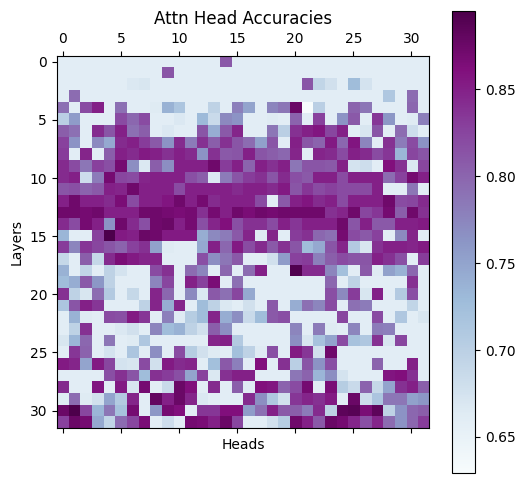

In [58]:
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(predictor_accuracies, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Attn Head Accuracies')
fig.colorbar(pos, ax=ax)
#plt.savefig(
#    "../data/01_14_26/predictor_accuracy.png",
#    bbox_inches='tight'
#)

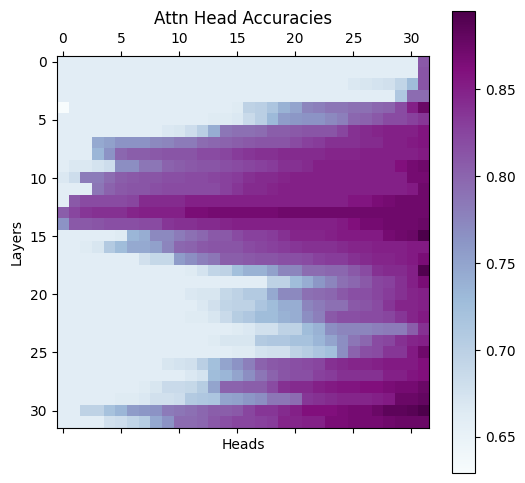

In [59]:
predictor_accuracy_sorted = np.sort(predictor_accuracies, axis=1)
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(predictor_accuracy_sorted, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Attn Head Accuracies')
fig.colorbar(pos, ax=ax)
#plt.savefig(
#    "../data/01_14_26/predictor_accuracy_sorted.png",
#    bbox_inches='tight'
#)

In [60]:
np.max(predictor_accuracies)

0.8951310861423221

In [61]:
# Sort (layer, head) pairs by accuracy descending
# predictor_accuracies is shape (n_layers, n_heads)
flat_sorted_idx = np.argsort(predictor_accuracies.ravel())[::-1]  # descending
sorted_index_pairs = list(zip(*np.unravel_index(flat_sorted_idx, predictor_accuracies.shape)))

# Optional sanity check
# print('Top-5:', [(p, predictor_accuracies[p]) for p in sorted_index_pairs[:5]])

In [64]:
# Select top-k attention heads
TOP_K = 5
selected_index_pairs = sorted_index_pairs[:TOP_K]

selected_attn_data = []
for layer, head in selected_index_pairs:
    dataset_idx = layer * 32 + head  # must match how `datasets` was constructed
    X_head, _y = datasets[dataset_idx]
    selected_attn_data.append(X_head)

# Concatenate selected heads' features
X = np.concatenate(selected_attn_data, axis=1) if len(selected_attn_data) > 1 else selected_attn_data[0]
y = validation_labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

y_true = np.asarray(y_test).astype(bool)
y_pred_bool = np.asarray(y_pred).astype(bool)

tp = int(((y_pred_bool == True) & (y_true == True)).sum())
tn = int(((y_pred_bool == False) & (y_true == False)).sum())
fp = int(((y_pred_bool == True) & (y_true == False)).sum())
fn = int(((y_pred_bool == False) & (y_true == True)).sum())

accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else float('nan')
denom = fp + tn
fpr = (fp / denom) if denom > 0 else float('nan')

print(f"Attn head model: TP={tp}, FP={fp}, TN={tn}, FN={fn}")
print(f"Attn head model accuracy: {accuracy:.4f}")
print(f"Attn head model false positive rate (FP/(FP+TN)): {fpr:.4f}")

Attn head model: TP=168, FP=11, TN=80, FN=8
Attn head model accuracy: 0.9288
Attn head model false positive rate (FP/(FP+TN)): 0.1209


### Calibration (reliability)
To check whether the model's predicted probabilities match empirical frequencies (e.g., ~90% of examples with ~0.9 predicted probability are truly positive), we can plot a reliability diagram (calibration curve) and compute calibration metrics like the Brier score.


In [ ]:
# Predicted probabilities for the positive class
idxs = np.where(result_df['judgement_llama'].to_numpy())[0]
idxs_true_positive = np.where(result_df['judgement_llama'].to_numpy() & result_df['validation'].to_numpy())[0]
idxs_false_positive = np.where(result_df['judgement_llama'].to_numpy() & ~result_df['validation'].to_numpy())[0]
p_true_positive = result_df['judgement_confidence_llama'].to_numpy()[idxs_true_positive]
p_false_positive = result_df['judgement_confidence_llama'].to_numpy()[idxs_false_positive]

p_test = result_df['judgement_confidence_llama'].to_numpy()[idxs]
y_test = result_df['validation'].to_numpy()[idxs]

# Reliability diagram data
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy='uniform')

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

# (1) Calibration diagram
ax[0].plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax[0].plot(mean_pred, frac_pos, marker="o")
ax[0].set_xlabel("Next token probability")
ax[0].set_ylabel("Fraction of positives")
ax[0].set_title("Llama Calibration")
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].legend()

# (2) Probability histogram
bins = np.linspace(0.0, 1.0, 11)  # 20 equal-width bins on [0, 1]
sns.histplot(
    p_true_positive,
    bins=bins,
    stat="probability",
    color="tab:blue",
    alpha=0.35,
    label=f"true_positive (n={len(p_true_positive)})",
    ax=ax[1],
)

sns.histplot(
    p_false_positive,
    bins=bins,
    stat="probability",
    color="tab:orange",
    alpha=0.35,
    label=f"false_positive (n={len(p_false_positive)})",
    ax=ax[1],
)

ax[1].set_xlim(0, 1)
ax[1].set_xlabel("Next Token Probability")
ax[1].set_ylabel("Probability")
ax[1].set_title("Next token probability histogram")
ax[1].legend()
ax[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


Brier score (lower is better): 0.0659


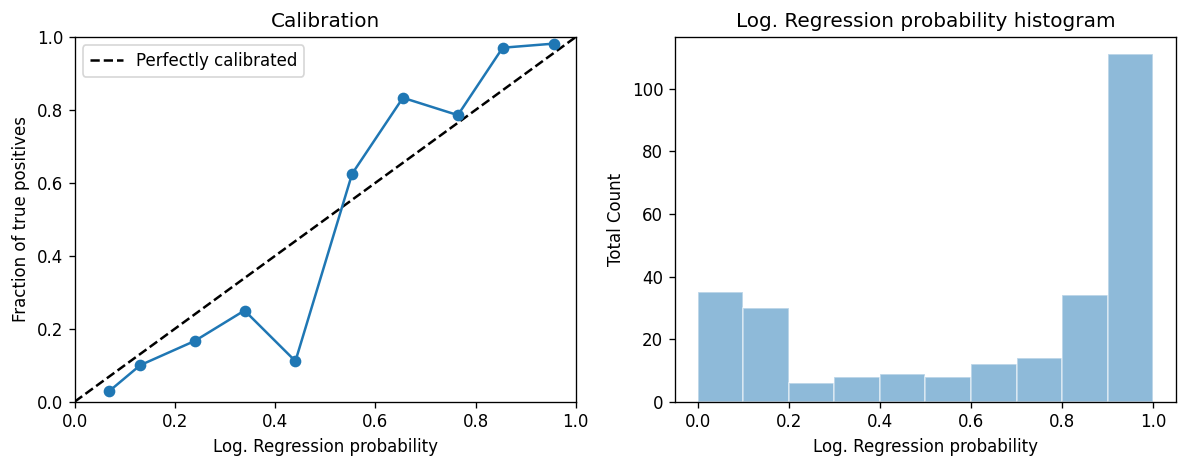

In [72]:
# Predicted probabilities for the positive class
p_test = log_reg.predict_proba(X_test)[:, 1]

# Reliability diagram data
# strategy='quantile' ensures roughly equal counts per bin; 'uniform' uses fixed-width bins
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy='uniform')

brier = brier_score_loss(y_test, p_test)
print(f"Brier score (lower is better): {brier:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

# (1) Calibration diagram
ax[0].plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
ax[0].plot(mean_pred, frac_pos, marker="o")
ax[0].set_xlabel("Log. Regression probability")
ax[0].set_ylabel("Fraction of true positives")
ax[0].set_title("Calibration")
ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[0].legend()

# (2) Probability histogram
ax[1].hist(p_test, bins=10, range=(0, 1), edgecolor="white", alpha=0.5)
ax[1].set_xlabel("Log. Regression probability")
ax[1].set_ylabel("Total Count")
ax[1].set_title("Log. Regression probability histogram")

plt.tight_layout()
plt.show()


### Manually validated results

In [72]:
with open("../data/12_11_25/pond_validated.json", "r") as f:
    validated_dict = json.load(f)

validated_df = pd.DataFrame(validated_dict)
#validated_df = validated_df.loc[validated_df.validation_status == "deviation"]

measure_ids = [mid for mid in validated_df.measurement_id if (mid in result_df.measurement_id.to_list()) and (mid != 924)]
judgement_df = result_df.loc[result_df.measurement_id.isin(measure_ids)]
judgement_df = judgement_df.sort_values(by = "measurement_id")
validated_df = validated_df.loc[validated_df.measurement_id.isin(measure_ids)]
validated_df = validated_df.sort_values(by = "measurement_id")

'''
matched_ex_df['validation_status'] = 'valid'
matched_ex_df['unit_status'] = True
matched_ex_df['ocr_status'] = True

validated_df = pd.concat([matched_ex_df.sample(n = 900, random_state = 42), validated_df], ignore_index=True)

# Shuffle the validated dataframe
validated_df = validated_df.sample(frac=1, random_state=42).reset_index(drop=True)
'''

"\nmatched_ex_df['validation_status'] = 'valid'\nmatched_ex_df['unit_status'] = True\nmatched_ex_df['ocr_status'] = True\n\nvalidated_df = pd.concat([matched_ex_df.sample(n = 900, random_state = 42), validated_df], ignore_index=True)\n\n# Shuffle the validated dataframe\nvalidated_df = validated_df.sample(frac=1, random_state=42).reset_index(drop=True)\n"

In [75]:
validated_df

,title,author,year,paper_code,document_id,context,name,date,location,ecosystem,measurement_id,measurement,page_id,value,unit_status,ocr_status,validation_status,units
1,bacterial processes and biogeochemical changes...,attermeyer; katrin; grossart; hans-peter; flur...,2017,bacterial_processes,5,<PAGE_0>\n\nBacterial processes and biogeochem...,Kettle Hole 6,2014-06-24,"53.416N 13.666E, north-eastern Germany",kettle hole,4468,surface_area,1,0.129,False,True,valid,km^2
21,daphnia diversity in water bodies of the po ri...,markova et al.,2017,daphnia_diversity,21,<PAGE_0>\n\nDaphnia diversity in water bodies ...,Bosco Braca pond,2014,Po River Basin,pond,4719,surface_area,2,2460,True,True,valid,m^2
22,daphnia diversity in water bodies of the po ri...,markova et al.,2017,daphnia_diversity,21,<PAGE_0>\n\nDaphnia diversity in water bodies ...,Motta pond,2014,Po River Basin,pond,4732,surface_area,2,2230,True,True,valid,m^2
24,diel vertical migrations of zooplankton in a s...,gilbert & hampton,2001,diel_vertical_migrations,23,<PAGE_0>\n\nDiel vertical migrations of zoopla...,Johnson Pond,1998-07-01,"Norwich, Vermont, U.S.A.",pond,4759,surface_area,2,0.1,False,True,valid,km^2
25,distinct optical chemistry of dissolved organi...,mcenroe et al,2013,distinct_optical,25,<PAGE_0>\n\nDistinct Optical Chemistry of Diss...,19-4,2009-06,"Richmond Hill, Canada",pond,4787,surface_area,1,2098,True,True,disorientation,m^2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,net heterotrophy in small danish lakes: a wide...,sand-jensen,2009,net_heterotrophy,67,<PAGE_0>\n\nNet Heterotrophy in Small Danish L...,Fønstrup dam,2001-11-01,"North Zealand, Denmark",lake,18643,chla,2,19.6,True,True,valid,µg/L
72,physical and chemical limnological characteris...,lim et al.,2001,physical_and_chemical_limnological,74,"<PAGE_0>\n\n1Darlene S. S. Lim, 1Marianne S. V...",BAG,1994-07-14,"76°23.18 N, 98°52.05 W",pond,18824,chla,17,1.7,True,True,valid,µg/L
75,production of fish populations in lakes,downing and plante,1993,production_of_fish,80,<PAGE_0>\n\nProduction of Fish Populations in ...,Kiutajärvi,None,None,lake,18920,chla,4,10,True,True,disorientation,µg/L
87,strength of phytoplankton-nutrient relationshi...,teissier; samuel; peretyatko; anatoly; de back...,2012,strength_of_phytoplankton,103,<PAGE_0>\n\nStrength of phytoplankton–nutrient...,Pond Beml,2006,Brussels Capital Region (Belgium),pond,19369,chla,1,23.4,True,True,valid,µg/L


In [76]:
judgement_df

,title,author,year,paper_code,document_id,context,name,date,location,ecosystem,measurement_id,measurement,page_id,value,units,judgement,processed_value
246,bacterial processes and biogeochemical changes...,attermeyer; katrin; grossart; hans-peter; flur...,2017.0,bacterial_processes,5,<PAGE_0>\n\nBacterial processes and biogeochem...,Kettle Hole 6,2014-06-24,"53.416N 13.666E, north-eastern Germany",kettle hole,4468,surface_area,1,0.129,km^2,valid,129000.0
1102,daphnia diversity in water bodies of the po ri...,markova et al.,2017.0,daphnia_diversity,21,<PAGE_0>\n\nDaphnia diversity in water bodies ...,Bosco Braca pond,2014,Po River Basin,pond,4719,surface_area,2,2460.000,m^2,valid,2460.0
1123,daphnia diversity in water bodies of the po ri...,markova et al.,2017.0,daphnia_diversity,21,<PAGE_0>\n\nDaphnia diversity in water bodies ...,Motta pond,2014,Po River Basin,pond,4732,surface_area,2,2230.000,m^2,valid,2230.0
1252,diel vertical migrations of zooplankton in a s...,gilbert & hampton,2001.0,diel_vertical_migrations,23,<PAGE_0>\n\nDiel vertical migrations of zoopla...,Johnson Pond,1998-07-01,"Norwich, Vermont, U.S.A.",pond,4759,surface_area,2,0.100,km^2,disorientation,100000.0
1304,distinct optical chemistry of dissolved organi...,mcenroe et al,2013.0,distinct_optical,25,<PAGE_0>\n\nDistinct Optical Chemistry of Diss...,19-4,2009-06,"Richmond Hill, Canada",pond,4787,surface_area,1,2098.000,m^2,valid,2098.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3203,net heterotrophy in small danish lakes: a wide...,sand-jensen,2009.0,net_heterotrophy,67,<PAGE_0>\n\nNet Heterotrophy in Small Danish L...,Fønstrup dam,2001-11-01,"North Zealand, Denmark",lake,18643,chla,2,19.600,µg/L,valid,19.6
3497,physical and chemical limnological characteris...,lim et al.,2001.0,physical_and_chemical_limnological,74,"<PAGE_0>\n\n1Darlene S. S. Lim, 1Marianne S. V...",BAG,1994-07-14,"76°23.18 N, 98°52.05 W",pond,18824,chla,17,1.700,µg/L,valid,1.7
4194,production of fish populations in lakes,downing and plante,1993.0,production_of_fish,80,<PAGE_0>\n\nProduction of Fish Populations in ...,Kiutajärvi,None,None,lake,18920,chla,4,10.000,µg/L,deviation,10.0
5341,strength of phytoplankton-nutrient relationshi...,teissier; samuel; peretyatko; anatoly; de back...,2012.0,strength_of_phytoplankton,103,<PAGE_0>\n\nStrength of phytoplankton–nutrient...,Pond Beml,2006,Brussels Capital Region (Belgium),pond,19369,chla,1,23.400,µg/L,valid,23.4


### LLM as Judge Baseline

In [77]:
# Complete accuracy calculation
judge_array = judgement_df.judgement.to_numpy()
#judge_array = validated_df.judgement.to_numpy()
validation_array = validated_df.validation_status.to_numpy()
(judge_array == validation_array).sum() / len(validation_array)

0.5217391304347826

In [78]:
# Recall -- for each type
status_type = 'deviation'
select = np.where(validation_array == status_type)[0]
(judge_array[select] == validation_array[select]).sum() / len(select)

0.2

In [79]:
# Valid / Invalid false positive rate
select = np.where(validation_array != 'valid')[0]
(judge_array[select] == 'valid').sum() / len(select)

0.5416666666666666

In [81]:
judge_array[select]

array(['valid', 'valid', 'disorientation', 'valid', 'deviation', 'valid',
       'hallucination', 'valid', 'disorientation', 'valid', 'valid',
       'valid', 'valid', 'hallucination', 'deviation', 'deviation',
       'hallucination', 'valid', 'hallucination', 'valid',
       'hallucination', 'valid', 'valid', 'deviation'], dtype=object)

In [80]:
judgement_df.judgement.value_counts()

judgement
valid             59
hallucination     16
deviation          9
disorientation     8
Name: count, dtype: int64

### Interpretability Scores

In [70]:
# Load data:
linear_probes = []
hallucination_scores = []
copying_scores = []

for i, row in validated_df.iterrows():
    measurement_id = row['measurement_id']
    loaded_scores = np.load(f"../data/pond_page_chunks2/{measurement_id}.npz")

    # Take results from first generated token
    linear_probes.append(loaded_scores['linear_probes'][0])

    # Average scores over all generated tokens
    parametric_scores = loaded_scores['parametric_scores'].mean(axis=0)
    context_scores = loaded_scores['context_scores'].mean(axis=0).flatten()
    hallucination_scores.append(np.concatenate([parametric_scores, context_scores]))

    # Flatten copying scores
    copying_scores.append(loaded_scores['copying_scores'].flatten())

linear_probes = np.array(linear_probes)
hallucination_scores = np.array(hallucination_scores)
copying_scores = np.array(copying_scores)


##### Linear Probe

In [82]:
status_dict = {
    'valid': 1,
    'hallucination': 0,
    'disorientation': 0,
    'deviation': 0,
}

X = linear_probes
y = validated_df['validation_status'].map(status_dict)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
# Fitting regularization parameter for logistic regression
regularization_params = np.linspace(0.0, 0.1, 101)
scores = np.empty((len(regularization_params), 5))

for i, alpha in enumerate(regularization_params):
    model = LogisticRegression(C=1/(alpha + 1e-10), penalty = "l1", solver = "liblinear", max_iter=1000)
    cv_results = cross_validate(model, X, y, cv=5, scoring='accuracy')
    scores[i, :] = cv_results['test_score']

In [85]:
np.mean(scores, axis=1)

array([0.937, 0.938, 0.936, 0.936, 0.938, 0.934, 0.932, 0.935, 0.937,
       0.939, 0.937, 0.937, 0.938, 0.936, 0.939, 0.936, 0.937, 0.937,
       0.939, 0.936, 0.937, 0.939, 0.934, 0.935, 0.936, 0.934, 0.936,
       0.936, 0.935, 0.934, 0.936, 0.936, 0.936, 0.936, 0.935, 0.934,
       0.936, 0.939, 0.937, 0.932, 0.935, 0.935, 0.937, 0.934, 0.934,
       0.935, 0.934, 0.936, 0.933, 0.936, 0.936, 0.936, 0.936, 0.933,
       0.934, 0.937, 0.935, 0.937, 0.934, 0.936, 0.933, 0.935, 0.936,
       0.937, 0.935, 0.934, 0.936, 0.937, 0.936, 0.933, 0.936, 0.936,
       0.935, 0.935, 0.935, 0.934, 0.936, 0.935, 0.936, 0.938, 0.937,
       0.936, 0.935, 0.936, 0.936, 0.933, 0.935, 0.934, 0.935, 0.934,
       0.937, 0.935, 0.937, 0.931, 0.934, 0.937, 0.933, 0.932, 0.935,
       0.934, 0.933])

Text(0, 0.5, 'Reconstruction Error')

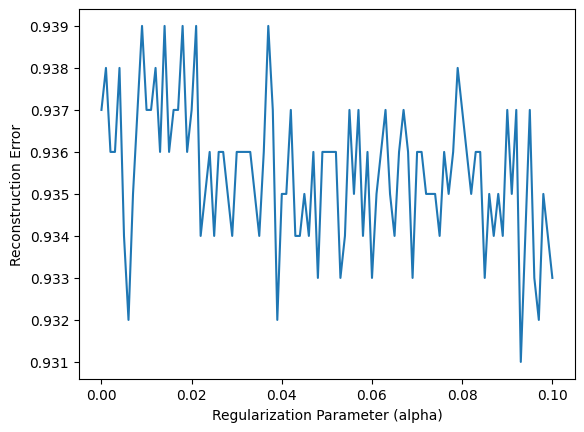

In [86]:
plt.plot(regularization_params, np.mean(scores, axis = 1))
plt.xlabel('Regularization Parameter (alpha)')
plt.ylabel('Reconstruction Error')

##### Hallucination Scores

In [88]:
status_dict = {
    'valid': 1,
    'hallucination': 0,
    'disorientation': 1,
    'deviation': 1,
}

X = hallucination_scores
y = validated_df['validation_status'].map(status_dict)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
X.shape

(1000, 1056)

In [ ]:
regularization_params[np.argmax(np.mean(scores, axis=1))]

In [ ]:
# Fit logistic regression model
alpha = 9e-05
model = LogisticRegression(C = 1/(alpha + 1e-10), penalty = "l1", solver='liblinear', max_iter=1000, random_state = 342)
model.fit(X, y)
#train_accuracy = model.score(X_train, y_train)
#print(f"Logistic Regression Train Accuracy: {train_accuracy:.4f}")
#accuracy = model.score(X, y)
#print(f"Logistic Regression Test Accuracy: {accuracy:.4f}")

coefficients = model.coef_[0]
context_coefficients = coefficients[:-32].reshape(32, 32)
parametric_coefficients = coefficients[-32:]

In [ ]:
model.predict(X_test)

In [ ]:
y_test

In [ ]:
pond_df

In [ ]:
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(context_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Context Score Coefficients')
fig.colorbar(pos, ax=ax)

In [ ]:
fig,ax = plt.subplots(figsize=(6,4), dpi = 100)
ax.bar(
    range(len(parametric_coefficients)), parametric_coefficients, alpha = 0.5
)
ax.set_ylabel('Parametric Score Coefficients')
ax.set_xlabel('Layers')

In [78]:
hallucination_indices = [i for i,entry in enumerate(result_dict_validated) if entry['validation_status'] == 'hallucination']

In [79]:
hallucination_indices

[26, 42]

In [100]:
result_dict_validated[26]

{'title': 'aquatic insect assemblages of man-made permanent ponds; buenos aires city; argentina',
 'author': 'fontanarrosa',
 'year': 2013,
 'context': '<table>\n  <tr>\n    <th></th>\n    <th>P1</th>\n    <th>P2</th>\n    <th>P3</th>\n    <th>P4</th>\n  </tr>\n  <tr>\n    <td>Area (\\( \\mathrm{m}^2 \\))</td>\n    <td>4,700</td>\n    <td>9,500</td>\n    <td>99,700</td>\n    <td>49,400</td>\n  </tr>\n  <tr>\n    <td>Max. depth (m)</td>\n    <td>\\( \\approx 1 \\)</td>\n    <td>\\( \\approx 1 \\)</td>\n    <td>\\( \\approx 5 \\)</td>\n    <td>\\( \\approx 1 \\)</td>\n  </tr>\n  <tr>\n    <td>Substrate</td>\n    <td>Natural</td>\n    <td>Natural</td>\n    <td>Natural</td>\n    <td>Natural</td>\n  </tr>\n  <tr>\n    <td>Shoreline</td>\n    <td>Natural</td>\n    <td>Concrete and granite (sloping)</td>\n    <td>Concrete and granite (sloping)</td>\n    <td>Concrete (vertical)</td>\n  </tr>\n  <tr>\n    <td>Aquatic vegetation</td>\n    <td>Poorly represent and frequently removed</td>\n    <td

In [108]:
idx1 = 25
datapoint1 = result_dict_validated[idx1]

idx2 = 26
datapoint2 = result_dict_validated[idx2]

(-0.05, 0.05)

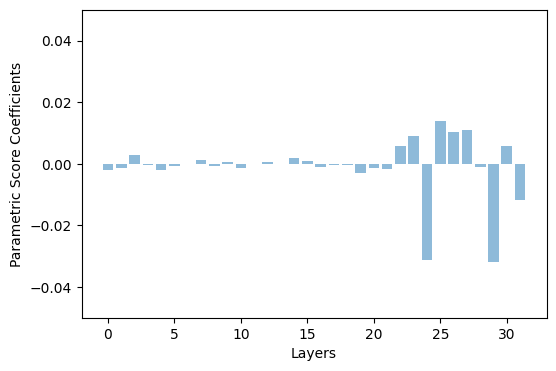

In [110]:
# parametric knowledge scores:
parametric_coefficients1 = datapoint1['parametric_scores']
parametric_coefficients1 = np.array([parametric_coefficients1.get(f'l{i}') for i in range(32)])

parametric_coefficients2 = datapoint2['parametric_scores']
parametric_coefficients2 = np.array([parametric_coefficients2.get(f'l{i}') for i in range(32)])

fig,ax = plt.subplots(figsize=(6,4), dpi = 100)
ax.bar(
    range(len(parametric_coefficients)), parametric_coefficients1 - parametric_coefficients2, alpha = 0.5
)
ax.set_ylabel('Parametric Score Coefficients')
ax.set_xlabel('Layers')
ax.set_ylim(-0.05, 0.05)

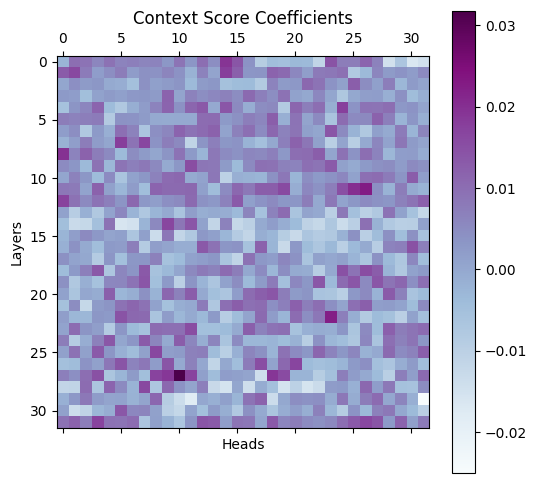

In [111]:
context_coefficients = np.zeros((32,32))
for layer in range(32):
    for head in range(32):
        context_coefficients[layer, head] = datapoint1['context_scores'].get(f'l{layer}h{head}', 0.0) - datapoint2['context_scores'].get(f'l{layer}h{head}', 0.0)
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(context_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Context Score Coefficients')
fig.colorbar(pos, ax=ax)




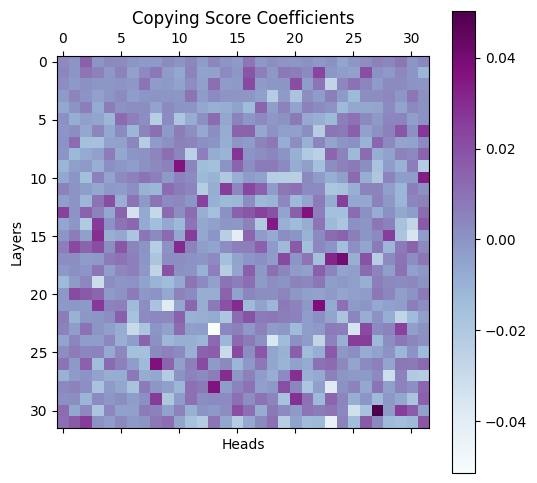

In [112]:
copying_coefficients = np.zeros((32,32))
for layer in range(32):
    for head in range(32):
        copying_coefficients[layer, head] = context_coefficients[layer, head] = datapoint1['copying_scores'].get(f'l{layer}h{head}', 0.0) - datapoint2['copying_scores'].get(f'l{layer}h{head}', 0.0)
fig,ax = plt.subplots(figsize=(6,6), dpi = 100)
pos = ax.matshow(copying_coefficients, cmap='BuPu')
ax.set_ylabel('Layers')
ax.set_xlabel('Heads')
ax.set_title(f'Copying Score Coefficients')
fig.colorbar(pos, ax=ax)

In [74]:
result_df

,title,author,year,paper_id,location,chunk_id,date,context,ecosystem,name,measurement,value,units,judgement,processed_value
0,agricultural freshwater pond supports diverse ...,chopyk et al.,2018.0,0,"central Maryland, United States",18,2016-10-01,Ten-liter water samples were collected in Octo...,pond,temperate freshwater agricultural pond,max_depth,3.35,m,valid,3.35
1,agricultural freshwater pond supports diverse ...,chopyk et al.,2018.0,0,None,40,October,<table>\n <tr>\n <th>Water property</th>\n...,pond,Agricultural pond,ph,7.70,NaN,valid,7.70
2,agricultural freshwater pond supports diverse ...,chopyk et al.,2018.0,0,"central Maryland, United States",18,2016-12-01,Ten-liter water samples were collected in Octo...,pond,temperate freshwater agricultural pond,surface_area,0.26,ha,valid,2600.00
3,agricultural freshwater pond supports diverse ...,chopyk et al.,2018.0,0,"central Maryland, United States",18,2016-10-01,Ten-liter water samples were collected in Octo...,pond,temperate freshwater agricultural pond,surface_area,0.26,ha,valid,2600.00
4,agricultural freshwater pond supports diverse ...,chopyk et al.,2018.0,0,None,40,November,<table>\n <tr>\n <th>Water property</th>\n...,pond,Agricultural pond,ph,7.56,NaN,valid,7.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4371,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017.0,127,None,28,None,<table>\n <tr>\n <th>Variable</th>\n <t...,wetland,Ardal,chla,7.20,µg/L,valid,7.20
4372,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017.0,127,None,28,None,<table>\n <tr>\n <th>Variable</th>\n <t...,wetland,Orcera,ph,8.10,NaN,valid,8.10
4373,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017.0,127,None,28,None,<table>\n <tr>\n <th>Variable</th>\n <t...,wetland,Castillo,ph,8.30,NaN,valid,8.30
4374,zooplankton body size versus taxonomy in medit...,gilbert; juan diego; de vicente; inmaculada; j...,2017.0,127,None,28,None,<table>\n <tr>\n <th>Variable</th>\n <t...,wetland,Quinta Casillas,chla,8.80,µg/L,valid,8.80
